# Value Estimator Variance Analysis

This notebook analyzes the variance of different value estimation methods compared to Monte Carlo.

For each state and method, we:
1. Compute mean and variance of predictions across different training batches
2. Calculate variance ratio: Var(method) / Var(MC)
3. Plot histogram of variance ratios

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Predictions Data

In [3]:
# Configure experiment to analyze
EXPERIMENT_ID = "cartpole_test"  # Change this to your experiment ID
EXPERIMENT_DIR = Path(f"experiments/{EXPERIMENT_ID}")
RESULTS_DIR = EXPERIMENT_DIR / "results"

# Load predictions
predictions_file = RESULTS_DIR / "predictions.csv"
if predictions_file.exists():
    df = pd.read_csv(predictions_file)
    print(f"Loaded {len(df)} predictions")
    print(f"\nDataset shape:")
    print(f"  States: {df['state_idx'].nunique()}")
    print(f"  Methods: {df['method'].nunique()}")
    print(f"  Batches: {df['batch_idx'].nunique()}")
    print(f"\nMethods: {sorted(df['method'].unique())}")
    print(f"\nFirst few rows:")
    display(df.head(10))
else:
    print(f"ERROR: Predictions file not found at {predictions_file}")
    print("Please run: python -m src.evaluate --config <your_config>.yaml")

Loaded 3287580 predictions

Dataset shape:
  States: 164379
  Methods: 2
  Batches: 10

Methods: ['dqn', 'monte_carlo']

First few rows:


,state_idx,method,batch_idx,predicted_value
0,0,monte_carlo,0,76.949290
1,1,monte_carlo,0,75.469860
2,2,monte_carlo,0,77.009590
3,3,monte_carlo,0,75.257866
4,4,monte_carlo,0,76.807060
5,5,monte_carlo,0,74.068340
6,6,monte_carlo,0,76.443760
7,7,monte_carlo,0,77.100030
8,8,monte_carlo,0,76.707280
9,9,monte_carlo,0,72.419490


## 2. Compute Mean and Variance per State

In [16]:
# Group by state and method, compute statistics across batches
stats = df.groupby(['state_idx', 'method'])['predicted_value'].agg(
    mean='mean',
    variance='var',
    std='std',
    count='count'
).reset_index()

print(f"Computed statistics for {len(stats)} (state, method) pairs")
print(f"\nExample statistics:")
display(stats.head(10))

# Check for missing data
print(f"\nMissing values:")
print(stats.isnull().sum())

Computed statistics for 328758 (state, method) pairs

Example statistics:


,state_idx,method,mean,variance,std,count
0,0,dqn,75.219331,0.487393,0.698135,8
1,0,monte_carlo,76.415673,1.771322,1.330910,8
2,1,dqn,74.286226,0.538148,0.733586,8
3,1,monte_carlo,74.954216,2.101848,1.449775,8
4,2,dqn,74.979433,0.505264,0.710819,8
5,2,monte_carlo,76.098499,1.981267,1.407575,8
6,3,dqn,73.869631,0.604585,0.777551,8
7,3,monte_carlo,74.420623,2.160335,1.469808,8
8,4,dqn,74.688608,0.564579,0.751385,8
9,4,monte_carlo,75.663007,2.032055,1.425502,8



Missing values:
state_idx    0
method       0
mean         0
variance     0
std          0
count        0
dtype: int64


## 3. General Function for Computing Log Ratios

In [17]:
def compute_log_ratios(stats_df, stat_column, stat_name):
    """
    Compute and plot log ratios of a statistic for each method against Monte Carlo.
    
    Args:
        stats_df: DataFrame with columns ['state_idx', 'method', stat_column]
        stat_column: Name of the column to compute ratios for (e.g., 'variance', 'mean')
        stat_name: Human-readable name for the statistic (e.g., 'Variance', 'Mean')
    """
    # Get Monte Carlo values
    mc_values = stats_df[stats_df['method'] == 'monte_carlo'][['state_idx', stat_column]]
    mc_values.columns = ['state_idx', 'mc_value']
    
    # Merge with all methods
    merged = stats_df.merge(mc_values, on='state_idx')
    
    # Compute log ratio
    merged['log_ratio'] = np.log(merged[stat_column] / merged['mc_value'])
    
    # Filter out Monte Carlo
    ratios = merged[merged['method'] != 'monte_carlo']
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    for method in sorted(ratios['method'].unique()):
        method_data = ratios[ratios['method'] == method]['log_ratio']
        ax.hist(method_data, bins=50, alpha=0.6, label=f'{method} (mean={method_data.mean():.3f})', edgecolor='black')
    
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Equal to MC')
    ax.set_xlabel(f'Log {stat_name} Ratio: log(Method / MC)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{stat_name} Log Ratio Distribution vs Monte Carlo', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save plot
    plot_file = RESULTS_DIR / f'{stat_column}_log_ratio.png'
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {plot_file}")
    plt.show()
    
    return ratios

print("Function defined: compute_log_ratios()")

Function defined: compute_log_ratios()


## 4. Compute Variance Ratios Against Monte Carlo

Saved plot to experiments/cartpole_test/results/variance_log_ratio.png


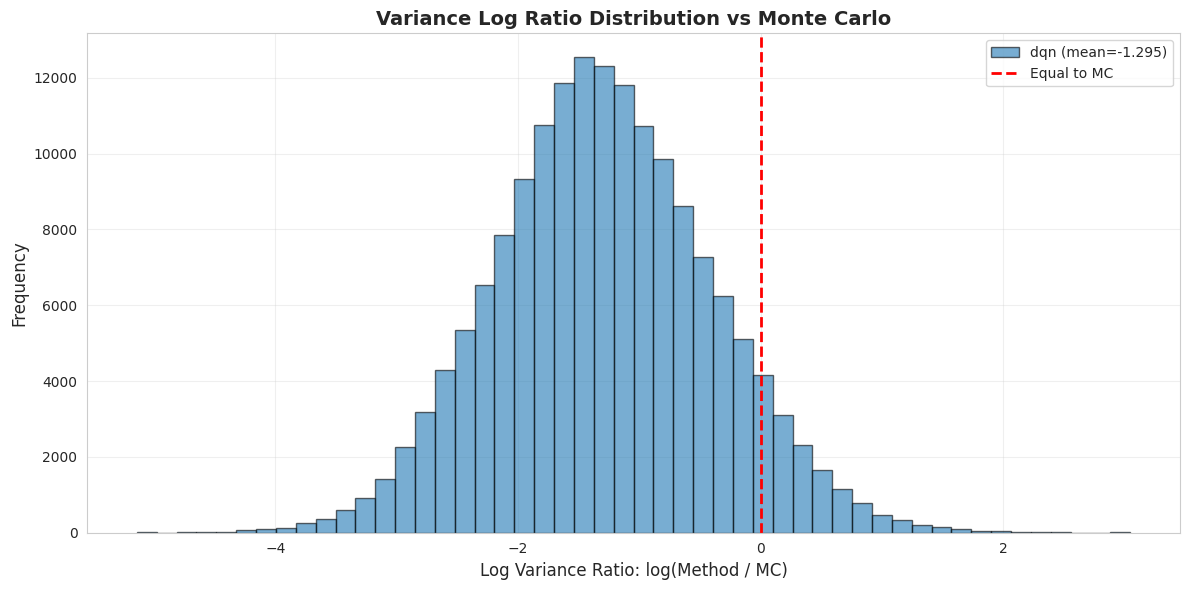

In [18]:
# Compute and plot variance log ratios
variance_ratios = compute_log_ratios(stats, 'variance', 'Variance')

/user/dc3430/pooling_eval/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Saved plot to experiments/cartpole_test/results/mean_log_ratio.png


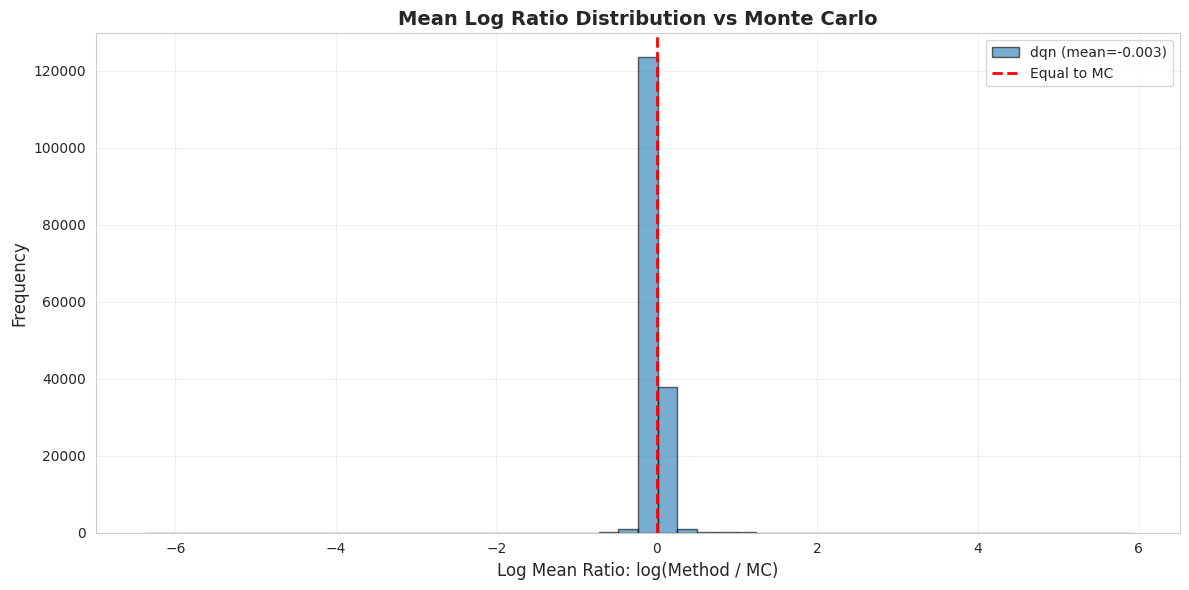

In [19]:
# Compute and plot mean log ratios
mean_ratios = compute_log_ratios(stats, 'mean', 'Mean')

In [11]:
df[(df['method'] == 'dqn') & (df['state_idx'] == 0)]

,state_idx,method,batch_idx,predicted_value
1643790,0,dqn,0,74.300354
1808169,0,dqn,1,75.301170
1972548,0,dqn,2,74.345050
2136927,0,dqn,3,67.003220
2301306,0,dqn,4,2.856031
2465685,0,dqn,5,74.719530
2630064,0,dqn,6,75.367520
2794443,0,dqn,7,75.849396
2958822,0,dqn,8,75.711400
3123201,0,dqn,9,76.160230


In [14]:
df = df[(df['batch_idx'] != 3) & (df['batch_idx'] != 4)]

In [15]:
df

,state_idx,method,batch_idx,predicted_value
0,0,monte_carlo,0,76.949290
1,1,monte_carlo,0,75.469860
2,2,monte_carlo,0,77.009590
3,3,monte_carlo,0,75.257866
4,4,monte_carlo,0,76.807060
...,...,...,...,...
3287575,164374,dqn,9,1.073935
3287576,164375,dqn,9,1.175216
3287577,164376,dqn,9,1.204009
3287578,164377,dqn,9,1.173560
